In [1]:
## CELL 1

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

# Suppress warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Set up the visual dashboard theme (Dark theme with Teal/Coral accents)
plt.style.use('dark_background')
sns.set_palette(['#008080', '#FF7F50', '#FFD700', '#708090']) # TEAL, CORAL, GOLD, SLATE

# Define the file path
file_path = '/Users/edu/Edu/testproject/tenderpilot_data/data/export_CAN_2023_2018.csv'

# Step 1: Define safe columns to load (The Absolute Leakage Exorcism)
# We strictly exclude post-award features like WIN_NAME, NUMBER_OFFERS, AWARD_VALUE_EURO, and YEAR.
columns_to_load = [
    # Identifiers & Target
    'ID_NOTICE_CAN', 
    'ID_AWARD',           # Unique identifier for the contract award level
    'INFO_ON_NON_AWARD',  # Empty if awarded; populated if unsuccessful/discontinued
    
    # Safe Pre-Award Features
    'TOP_TYPE',           # Type of procedure (e.g., Open, Restricted)
    'TYPE_OF_CONTRACT',   # Works, Supplies, or Services
    'B_ACCELERATED',      # Accelerated procedure flag
    'CRIT_CODE',          # Lowest price vs. MEAT
    'CRIT_PRICE_WEIGHT',  # Weight given to price
    'CPV',                # Main procurement vocabulary code
    'ISO_COUNTRY_CODE',   # Country
    'B_EU_FUNDS',         # EU funding flag
    'B_FRA_AGREEMENT',    # Framework agreement flag
    'B_DYN_PURCH_SYST',   # Dynamic purchasing system flag
    'AWARD_EST_VALUE_EURO'# The true pre-award estimated budget, avoiding lowest-bid leaks
]

print("Loading CAN dataset...")

# Step 2: Load the dataset using only the strictly safe columns
df = pd.read_csv(file_path, usecols=columns_to_load, low_memory=False)

# Step 3: Proper Deduplication at the Contract Award Level
original_size = len(df)
# We drop duplicates based on ID_AWARD, not the notice ID, to preserve multi-lot/multi-award data /TODO check
df = df.dropna(subset=['ID_AWARD']).drop_duplicates(subset=['ID_AWARD'])

print(f"Loaded {original_size} raw rows.")
print(f"After deduplicating by ID_AWARD: {len(df)} unique contract awards remain.")

# Preview the completely safe feature space
display(df.head())

Loading CAN dataset...
Loaded 6198063 raw rows.
After deduplicating by ID_AWARD: 5230355 unique contract awards remain.


,ID_NOTICE_CAN,ISO_COUNTRY_CODE,TYPE_OF_CONTRACT,B_FRA_AGREEMENT,B_DYN_PURCH_SYST,CPV,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,CRIT_CODE,CRIT_PRICE_WEIGHT,ID_AWARD,INFO_ON_NON_AWARD,AWARD_EST_VALUE_EURO
0,20184,DE,S,Y,N,72300000,Y,OPE,NaN,M,30,8447164.0,PROCUREMENT_UNSUCCESSFUL,NaN
1,20185,IT,S,Y,N,79411000,N,OPE,NaN,M,NaN,8447165.0,NaN,1500000.0
2,20185,IT,S,Y,N,79411000,N,OPE,NaN,M,NaN,8447166.0,NaN,1500000.0
3,20192,BE,S,N,N,79000000,Y,OPE,NaN,M,30 %,10169728.0,NaN,7440000.0
4,20193,BE,S,N,N,79000000,Y,OPE,NaN,M,30 %,10169729.0,NaN,1600000.0


In [2]:
## CELL 2

# Step 1: Structural Bias Fix (Remove Direct Awards)
# According to TED docs, AWP, NOC, and NOP bypass public competition. 
# We drop them so the model only evaluates true competitive procurements.
direct_award_types = ['NOC', 'NOP', 'AWP']
competitive_mask = ~df['TOP_TYPE'].isin(direct_award_types)

original_len = len(df)
df = df[competitive_mask].copy()
print(f"Removed {original_len - len(df)} direct award notices.")

# Step 2: Create the Honest Target Variable (y)
# If INFO_ON_NON_AWARD is missing (NaN), it means the contract WAS awarded (y=1).
# If it is populated, the contract was NOT awarded (y=0).
df['target'] = df['INFO_ON_NON_AWARD'].isna().astype(int)

# Step 3: Check the true competitive class distribution
target_counts = df['target'].value_counts()
awarded_count = target_counts.get(1, 0)
not_awarded_count = target_counts.get(0, 0)

print("\nCompetitive Target Distribution:")
print(f"Awarded (1):     {awarded_count:,}")
print(f"Not Awarded (0): {not_awarded_count:,}")
print(f"Percentage Not Awarded: {(not_awarded_count / len(df) * 100):.2f}%\n")

# Step 4: Calculate the true algorithmic calibration weight for XGBoost
# Formula: count(negative) / count(positive) // TODOS remove for balanced dataset
scale_pos_weight = not_awarded_count / awarded_count
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight:.4f}")

# Step 5: Drop the target-defining column and IDs to prevent data leakage
X = df.drop(columns=['INFO_ON_NON_AWARD', 'target', 'ID_NOTICE_CAN', 'ID_AWARD'])
y = df['target']

print("\nFeature matrix (X) shape:", X.shape)
print("Target vector (y) shape:", y.shape)

# Display a quick preview of the safe feature matrix
display(X.head())

Removed 187564 direct award notices.

Competitive Target Distribution:
Awarded (1):     4,081,767
Not Awarded (0): 961,024
Percentage Not Awarded: 19.06%

Calculated scale_pos_weight for XGBoost: 0.2354

Feature matrix (X) shape: (5042791, 11)
Target vector (y) shape: (5042791,)


,ISO_COUNTRY_CODE,TYPE_OF_CONTRACT,B_FRA_AGREEMENT,B_DYN_PURCH_SYST,CPV,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,CRIT_CODE,CRIT_PRICE_WEIGHT,AWARD_EST_VALUE_EURO
0,DE,S,Y,N,72300000,Y,OPE,NaN,M,30,NaN
1,IT,S,Y,N,79411000,N,OPE,NaN,M,NaN,1500000.0
2,IT,S,Y,N,79411000,N,OPE,NaN,M,NaN,1500000.0
3,BE,S,N,N,79000000,Y,OPE,NaN,M,30 %,7440000.0
4,BE,S,N,N,79000000,Y,OPE,NaN,M,30 %,1600000.0


In [3]:
# CELL 3: Final Sanitized Feature Engineering

print("Starting Final Sanitized Feature Engineering...")

# Step 1: Handle Structural Missingness in the TRUE Pre-Award Estimated Value
X['VALUE_EURO_MISSING'] = X['AWARD_EST_VALUE_EURO'].isna().astype(int)
X['VALUE_EURO_LOG'] = np.log1p(X['AWARD_EST_VALUE_EURO'].fillna(0))
X = X.drop(columns=['AWARD_EST_VALUE_EURO'])

# Step 2: Clean CRIT_PRICE_WEIGHT & Add Missing Indicator
# Fix: Flag missing weights before filling with 0 to separate "unreported" from "0% weight"
X['CRIT_PRICE_WEIGHT_MISSING'] = X['CRIT_PRICE_WEIGHT'].isna().astype(int)
X['CRIT_PRICE_WEIGHT'] = X['CRIT_PRICE_WEIGHT'].astype(str).str.replace('%', '').str.strip()
X['CRIT_PRICE_WEIGHT'] = pd.to_numeric(X['CRIT_PRICE_WEIGHT'], errors='coerce').fillna(0)

# Step 3: Binary Flag Mapping
binary_cols = ['B_FRA_AGREEMENT', 'B_DYN_PURCH_SYST', 'B_EU_FUNDS', 'B_ACCELERATED']
for col in binary_cols:
    X[col] = X[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

# Step 4: Categorical Grouping (Dimensionality Reduction)
X['CPV_DIVISION'] = X['CPV'].astype(str).str[:2]
X = X.drop(columns=['CPV'])

cat_cols = ['ISO_COUNTRY_CODE', 'TYPE_OF_CONTRACT', 'TOP_TYPE', 'CRIT_CODE', 'CPV_DIVISION']
for col in cat_cols:
    X[col] = X[col].fillna('UNKNOWN')

def group_low_freq(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    keep = freq[freq >= threshold].index
    return df[col].where(df[col].isin(keep), 'OTHER')

for col in cat_cols:
    X[col] = group_low_freq(X, col)

# Step 5: One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nFinal Sanitization Complete!")
print(f"Final feature matrix (X_encoded) shape: {X_encoded.shape}")


Starting Final Sanitized Feature Engineering...

Final Sanitization Complete!
Final feature matrix (X_encoded) shape: (5042791, 53)


Splitting data into Train (80%), Validation (10%), and Test (10%)...
Initializing XGBoost with exact train scale_pos_weight=0.2354...
Training the model (evaluating on separate validation set)...
[0]	validation_0-aucpr:0.97228
[50]	validation_0-aucpr:0.97740
[100]	validation_0-aucpr:0.97857
[150]	validation_0-aucpr:0.97917
[199]	validation_0-aucpr:0.97959

Generating predictions on the test set...

VECTYFI RADAR: RIGOROUS EVALUATION (TEST SET)
ROC-AUC Score: 0.9189
Minority Class (0) PR-AUC: 0.7805 (True performance on failed tenders)

Classification Report:
                 precision    recall  f1-score   support

Not Awarded (0)       0.53      0.82      0.64     96103
    Awarded (1)       0.95      0.83      0.89    408177

       accuracy                           0.83    504280
      macro avg       0.74      0.82      0.76    504280
   weighted avg       0.87      0.83      0.84    504280


TOP 15 MOST IMPORTANT FEATURES (By Information Gain)
1. VALUE_EURO_MISSING: 28894.8105
2.

<Figure size 1000x600 with 0 Axes>

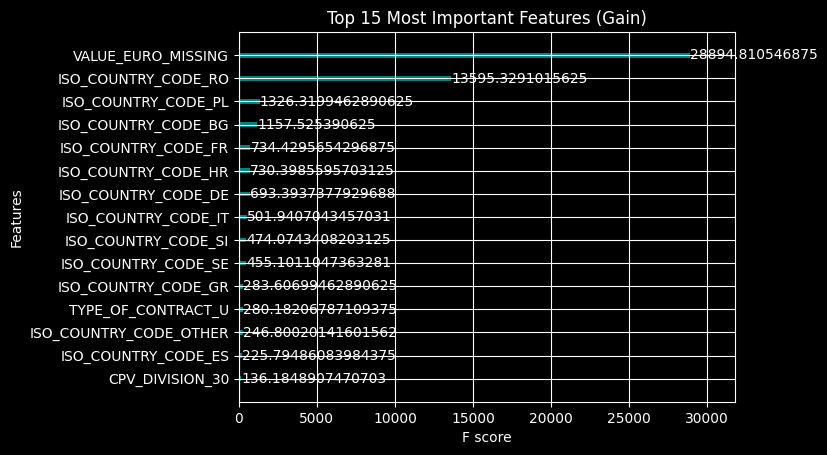

In [6]:
# CELL 4: Rigorous Modeling and Honest Evaluation

from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Step 1: Train-Validation-Test Split (Fixing eval_set contamination)
print("Splitting data into Train (80%), Validation (10%), and Test (10%)...")
# First isolate 10% for the ultimate unseen Test set
X_temp, X_test, y_temp, y_test = train_test_split(X_encoded, y, test_size=0.10, stratify=y, random_state=42)
# Then split the remaining 90% into Train and Validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42) 

# Dynamically calculate the perfect scale_pos_weight strictly for the training set
train_counts = y_train.value_counts()
exact_scale_pos_weight = train_counts.get(0, 0) / train_counts.get(1, 1)

# Step 2: Initialize Calibrated XGBoost
print(f"Initializing XGBoost with exact train scale_pos_weight={exact_scale_pos_weight:.4f}...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=exact_scale_pos_weight, 
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# Step 3: Train the model using the dedicated Validation Set
print("Training the model (evaluating on separate validation set)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Step 4: Generate Predictions on the UNSEEN Test Set
print("\nGenerating predictions on the test set...")
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_prob_minority = xgb_model.predict_proba(X_test)[:, 0] # Probabilities for the 'Not Awarded' class

# Step 5: Evaluate the Honest Baseline
roc_auc = roc_auc_score(y_test, y_prob)

# Calculate PR-AUC specifically for the Minority Class (y=0) to fix the misleading metric
precision_min, recall_min, _ = precision_recall_curve(1 - y_test, y_prob_minority)
pr_auc_minority = auc(recall_min, precision_min)

print("\n" + "="*55)
print("VECTYFI RADAR: RIGOROUS EVALUATION (TEST SET)")
print("="*55)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Minority Class (0) PR-AUC: {pr_auc_minority:.4f} (True performance on failed tenders)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Awarded (0)', 'Awarded (1)']))

# Step 6: Extract & Plot Feature Importances using 'gain' (Predictive Contribution)
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# FIXED: key=lambda x: x[1] correctly sorts by the score (the second element in the tuple)
sorted_importances = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*55)
print("TOP 15 MOST IMPORTANT FEATURES (By Information Gain)")
print("="*55)
for i, (feature, score) in enumerate(sorted_importances[:15], 1):
    print(f"{i}. {feature}: {score:.4f}")

# Plot Top 15 Feature Importances by Gain
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain', color='#008080', title='Top 15 Most Important Features (Gain)')
plt.show()